# Task 07 — Graph Explainability and Embedding Analysis
### CCS4354 — Tensors and Graphs | OGBN-Arxiv



## 1. Setup and Imports

In [ ]:
# Install required packages
!pip install -q torch-geometric ogb scikit-learn pandas matplotlib

In [ ]:
import os
import pickle
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from torch_geometric.nn import GCNConv, GATConv

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


## 2. Load the OGBN-Arxiv Dataset

Reusing the same loading logic as Task 03, so the node indices line up with the models
you already trained.

In [ ]:
DATASET_PATH = "processed_data.pkl"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATASET_PATH}'. "
        "Please upload it to the notebook environment."
    )

print(f"Loading dataset: {DATASET_PATH}")

# Try standard Python pickle first
try:
    with open(DATASET_PATH, "rb") as f:
        dataset = pickle.load(f)

    print("Dataset loaded using pickle.")

except Exception as pickle_error:

    print("Standard pickle loading failed.")
    print("Trying torch.load(...) instead...")

    try:
        dataset = torch.load(
            DATASET_PATH,
            map_location="cpu",
            weights_only=False
        )

        print("Dataset loaded using torch.load.")

    except Exception as torch_error:
        raise RuntimeError(
            "Could not load processed_data.pkl.\n\n"
            f"pickle error: {pickle_error}\n\n"
            f"torch.load error: {torch_error}"
        )


print("Loaded object type:", type(dataset))

Loading dataset: processed_data.pkl
Dataset loaded using pickle.
Loaded object type: <class 'dict'>


# Extract graph and train/validation/test indices

In [ ]:
import torch
from torch_geometric.data import Data

# ============================================================
# EXTRACT DATA FROM processed_data.pkl
# ============================================================

data = None
train_idx = None
valid_idx = None
test_idx = None

print("Dataset is a dictionary.")
print("Available keys:", list(dataset.keys()))

# ------------------------------------------------------------
# Extract features
# ------------------------------------------------------------

if "features" not in dataset:
    raise KeyError("Missing 'features' in processed_data.pkl")

x = dataset["features"]
print("Features found:", type(x))

# ------------------------------------------------------------
# Extract labels
# ------------------------------------------------------------

if "labels" not in dataset:
    raise KeyError("Missing 'labels' in processed_data.pkl")

y = dataset["labels"]
print("Labels found:", type(y))

# ------------------------------------------------------------
# Extract edge_index
# ------------------------------------------------------------

if "edge_index" not in dataset:
    raise KeyError("Missing 'edge_index' in processed_data.pkl")

edge_index = dataset["edge_index"]
print("Edge index found:", type(edge_index))

# ------------------------------------------------------------
# Extract train / validation / test indices
# ------------------------------------------------------------

if "train_idx" not in dataset:
    raise KeyError("Missing 'train_idx' in processed_data.pkl")

if "valid_idx" not in dataset:
    raise KeyError("Missing 'valid_idx' in processed_data.pkl")

if "test_idx" not in dataset:
    raise KeyError("Missing 'test_idx' in processed_data.pkl")

train_idx = dataset["train_idx"]
valid_idx = dataset["valid_idx"]
test_idx = dataset["test_idx"]

print("Training indices found.")
print("Validation indices found.")
print("Test indices found.")

# ============================================================
# CONVERT TO PYTORCH TENSORS
# ============================================================

x = torch.as_tensor(x, dtype=torch.float)

y = torch.as_tensor(y)

edge_index = torch.as_tensor(edge_index, dtype=torch.long)

train_idx = torch.as_tensor(train_idx, dtype=torch.long)
valid_idx = torch.as_tensor(valid_idx, dtype=torch.long)
test_idx = torch.as_tensor(test_idx, dtype=torch.long)

# ============================================================
# FIX LABEL SHAPE
# ============================================================

if y.dim() > 1 and y.shape[-1] == 1:
    y = y.squeeze(-1)

# ============================================================
# FIX EDGE INDEX SHAPE
# ============================================================

if edge_index.shape[0] != 2 and edge_index.shape[1] == 2:
    edge_index = edge_index.t()

# ============================================================
# CREATE PYTORCH GEOMETRIC DATA OBJECT
# ============================================================

data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

# ============================================================
# DISPLAY INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("GRAPH DATA CREATED SUCCESSFULLY")
print("=" * 60)

print(data)

print("\nGraph information:")
print("Number of nodes      :", data.num_nodes)
print("Number of edges      :", data.num_edges)
print("Number of features   :", data.num_node_features)
print("Number of classes    :", int(y.max().item()) + 1)

print("\nSplit information:")
print("Training nodes       :", len(train_idx))
print("Validation nodes     :", len(valid_idx))
print("Test nodes           :", len(test_idx))

print("\nTensor shapes:")
print("x shape              :", data.x.shape)
print("edge_index shape     :", data.edge_index.shape)
print("y shape              :", data.y.shape)

Dataset is a dictionary.
Available keys: ['features', 'labels', 'edge_index', 'train_idx', 'valid_idx', 'test_idx']
Features found: <class 'torch.Tensor'>
Labels found: <class 'torch.Tensor'>
Edge index found: <class 'torch.Tensor'>
Training indices found.
Validation indices found.
Test indices found.

GRAPH DATA CREATED SUCCESSFULLY
Data(x=[169343, 128], edge_index=[2, 1166243], y=[169343])

Graph information:
Number of nodes      : 169343
Number of edges      : 1166243
Number of features   : 128
Number of classes    : 40

Split information:
Training nodes       : 90941
Validation nodes     : 29799
Test nodes           : 48603

Tensor shapes:
x shape              : torch.Size([169343, 128])
edge_index shape     : torch.Size([2, 1166243])
y shape              : torch.Size([169343])


# Prepare labels and device

In [ ]:
# ============================================================
# PREPARE DATA
# ============================================================

# Labels may be [N, 1], so convert to [N]
if data.y.dim() > 1:
    data.y = data.y.squeeze(1)

# Move graph to GPU / CPU
data = data.to(device)


# ------------------------------------------------------------
# Dataset information
# ------------------------------------------------------------

num_nodes = data.num_nodes
num_edges = data.num_edges
in_channels = data.x.size(-1)

# Number of classes
num_classes = int(data.y.max().item()) + 1


print("\n========== DATASET INFORMATION ==========")
print(f"Nodes:       {num_nodes:,}")
print(f"Edges:       {num_edges:,}")
print(f"Features:    {in_channels}")
print(f"Classes:     {num_classes}")
print(f"x shape:     {tuple(data.x.shape)}")
print(f"edge_index:  {tuple(data.edge_index.shape)}")
print(f"y shape:     {tuple(data.y.shape)}")


# ------------------------------------------------------------
# Prepare split indices
# ------------------------------------------------------------

if train_idx is not None:
    train_idx = torch.as_tensor(
        train_idx,
        dtype=torch.long,
        device=device
    )

if valid_idx is not None:
    valid_idx = torch.as_tensor(
        valid_idx,
        dtype=torch.long,
        device=device
    )

if test_idx is not None:
    test_idx = torch.as_tensor(
        test_idx,
        dtype=torch.long,
        device=device
    )


# ------------------------------------------------------------
# Print split information
# ------------------------------------------------------------

print("\n========== DATA SPLITS ==========")

if train_idx is not None:
    print(f"Training nodes:   {len(train_idx):,}")
else:
    print("Training nodes:   Not available")

if valid_idx is not None:
    print(f"Validation nodes: {len(valid_idx):,}")
else:
    print("Validation nodes: Not available")

if test_idx is not None:
    print(f"Test nodes:       {len(test_idx):,}")
else:
    print("Test nodes:       Not available")


========== DATASET INFORMATION ==========
Nodes:       169,343
Edges:       1,166,243
Features:    128
Classes:     40
x shape:     (169343, 128)
edge_index:  (2, 1166243)
y shape:     (169343,)

========== DATA SPLITS ==========
Training nodes:   90,941
Validation nodes: 29,799
Test nodes:       48,603


# class names

In [ ]:
# ============================================================
# OPTIONAL CLASS NAMES
# ============================================================

idx2name = None

possible_label_files = [
    "labelidx2arxivcategeory.csv.gz",
    "labelidx2arxivcategory.csv.gz",
    "labelidx2arxivcategory.csv",
    "dataset/ogbn_arxiv/mapping/labelidx2arxivcategeory.csv.gz",
    "dataset/ogbn_arxiv/mapping/labelidx2arxivcategory.csv.gz"
]

for label_path in possible_label_files:

    if os.path.exists(label_path):

        try:
            label_df = pd.read_csv(label_path)

            print("Label mapping loaded from:")
            print(label_path)

            print("\nColumns:")
            print(label_df.columns.tolist())

            # Original OGB format
            if (
                "label idx" in label_df.columns
                and "arxiv category" in label_df.columns
            ):

                idx2name = dict(
                    zip(
                        label_df["label idx"],
                        label_df["arxiv category"]
                    )
                )

            break

        except Exception as e:
            print("Could not read label mapping:", e)

if idx2name is None:
    print(
        "\nNo class-name mapping found. "
        "Numeric class indices will be used."
    )
else:
    print("\nNumber of class names:", len(idx2name))

Label mapping loaded from:
dataset/ogbn_arxiv/mapping/labelidx2arxivcategeory.csv.gz

Columns:
['label idx', 'arxiv category']

Number of class names: 40


# Define GCN and GAT models

In [ ]:
# ============================================================
# GCN MODEL
# ============================================================

class GCN(torch.nn.Module):

    def __init__(
        self,
        in_channels=128,
        hidden_channels=256,
        out_channels=40,
        dropout=0.5
    ):

        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.bn1 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.bn2 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.conv3 = GCNConv(
            hidden_channels,
            out_channels
        )

        self.dropout = dropout


    def forward(
        self,
        x,
        edge_index,
        return_embedding=False
    ):

        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )


        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        # Penultimate representation
        embedding = x

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )


        # Output layer
        out = self.conv3(x, edge_index)


        if return_embedding:
            return out, embedding

        return out


# ============================================================
# GAT MODEL
# ============================================================

class GAT(torch.nn.Module):

    def __init__(
        self,
        in_channels=128,
        hidden_channels=64,
        out_channels=40,
        heads=4,
        dropout=0.5
    ):

        super().__init__()

        # First GAT layer
        self.conv1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=dropout
        )

        self.bn1 = torch.nn.BatchNorm1d(
            hidden_channels * heads
        )

        # Output GAT layer
        self.conv2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,
            dropout=dropout
        )

        self.dropout = dropout


    def forward(
        self,
        x,
        edge_index,
        return_embedding=False,
        return_attention=False
    ):

        # First layer + attention
        if return_attention:

            x1, (ei1, alpha1) = self.conv1(
                x,
                edge_index,
                return_attention_weights=True
            )

        else:

            x1 = self.conv1(
                x,
                edge_index
            )


        # Batch normalization + activation
        x1 = self.bn1(x1)
        x1 = F.elu(x1)

        # Penultimate representation
        embedding = x1

        x1 = F.dropout(
            x1,
            p=self.dropout,
            training=self.training
        )


        # Output layer
        if return_attention:

            out, (ei2, alpha2) = self.conv2(
                x1,
                edge_index,
                return_attention_weights=True
            )

            return (
                out,
                embedding,
                (ei1, alpha1),
                (ei2, alpha2)
            )


        out = self.conv2(
            x1,
            edge_index
        )


        if return_embedding:
            return out, embedding

        return out

# Load trained GCN and GAT models

In [ ]:
# ============================================================
# LOAD TRAINED MODELS
# ============================================================

GCN_CKPT_PATH = "gcn_final.pt"
GAT_CKPT_PATH = "gat_final.pt"


# ------------------------------------------------------------
# Check checkpoint files
# ------------------------------------------------------------

if not os.path.exists(GCN_CKPT_PATH):
    raise FileNotFoundError(
        f"Could not find {GCN_CKPT_PATH}"
    )

if not os.path.exists(GAT_CKPT_PATH):
    raise FileNotFoundError(
        f"Could not find {GAT_CKPT_PATH}"
    )


# ------------------------------------------------------------
# Create models
# ------------------------------------------------------------

gcn_model = GCN(
    in_channels=in_channels,
    hidden_channels=256,
    out_channels=num_classes
).to(device)


gat_model = GAT(
    in_channels=in_channels,
    hidden_channels=64,
    out_channels=num_classes,
    heads=4
).to(device)


# ------------------------------------------------------------
# Load checkpoints
# ------------------------------------------------------------

gcn_checkpoint = torch.load(
    GCN_CKPT_PATH,
    map_location=device,
    weights_only=False
)

gat_checkpoint = torch.load(
    GAT_CKPT_PATH,
    map_location=device,
    weights_only=False
)


# ------------------------------------------------------------
# Handle state_dict/checkpoint dictionaries
# ------------------------------------------------------------

if isinstance(gcn_checkpoint, dict) and "state_dict" in gcn_checkpoint:
    gcn_checkpoint = gcn_checkpoint["state_dict"]

if isinstance(gat_checkpoint, dict) and "state_dict" in gat_checkpoint:
    gat_checkpoint = gat_checkpoint["state_dict"]


# ------------------------------------------------------------
# Load weights
# ------------------------------------------------------------

gcn_model.load_state_dict(gcn_checkpoint)
gat_model.load_state_dict(gat_checkpoint)


# Evaluation mode
gcn_model.eval()
gat_model.eval()


print("====================================")
print("GCN checkpoint loaded successfully")
print("GAT checkpoint loaded successfully")
print("====================================")

GCN checkpoint loaded successfully
GAT checkpoint loaded successfully


# Test model predictions

In [ ]:
# ============================================================
# TEST MODEL PREDICTIONS
# ============================================================

with torch.no_grad():

    gcn_output = gcn_model(
        data.x,
        data.edge_index
    )

    gat_output = gat_model(
        data.x,
        data.edge_index
    )


gcn_predictions = gcn_output.argmax(dim=1)
gat_predictions = gat_output.argmax(dim=1)


print("GCN output shape:", tuple(gcn_output.shape))
print("GAT output shape:", tuple(gat_output.shape))

print("\nGCN sample predictions:")
print(gcn_predictions[:20].cpu().numpy())

print("\nGAT sample predictions:")
print(gat_predictions[:20].cpu().numpy())

GCN output shape: (169343, 40)
GAT output shape: (169343, 40)

GCN sample predictions:
[ 4  2 28  5 27 34 21 39 10 28 24 36 28 10 16  2 34 24 24 19]

GAT sample predictions:
[ 4  9 28 28 27 37  6 28  3 28 28 36 28 10 16  5  4 26 24 19]


# Calculate test accuracy

In [ ]:
# ============================================================
# TEST ACCURACY
# ============================================================

if test_idx is not None:

    with torch.no_grad():

        gcn_pred = gcn_model(
            data.x,
            data.edge_index
        ).argmax(dim=1)

        gat_pred = gat_model(
            data.x,
            data.edge_index
        ).argmax(dim=1)


    gcn_accuracy = (
        gcn_pred[test_idx] == data.y[test_idx]
    ).float().mean().item()


    gat_accuracy = (
        gat_pred[test_idx] == data.y[test_idx]
    ).float().mean().item()


    print(f"GCN Test Accuracy: {gcn_accuracy:.4f}")
    print(f"GAT Test Accuracy: {gat_accuracy:.4f}")

else:

    print(
        "test_idx was not found in processed_data.pkl. "
        "Skipping test accuracy."
    )

GCN Test Accuracy: 0.4110
GAT Test Accuracy: 0.5143


# Extract node embeddings

In [ ]:
# ============================================================
# NODE EMBEDDINGS
# ============================================================

with torch.no_grad():

    _, gcn_embeddings = gcn_model(
        data.x,
        data.edge_index,
        return_embedding=True
    )

    _, gat_embeddings = gat_model(
        data.x,
        data.edge_index,
        return_embedding=True
    )


# Move to CPU for sklearn
gcn_embeddings = gcn_embeddings.cpu().numpy()
gat_embeddings = gat_embeddings.cpu().numpy()

labels = data.y.cpu().numpy()


print("GCN embedding shape:")
print(gcn_embeddings.shape)

print("\nGAT embedding shape:")
print(gat_embeddings.shape)


# ------------------------------------------------------------
# Sample nodes for visualization
# ------------------------------------------------------------

sample_size = min(5000, len(labels))

rng = np.random.default_rng(42)

sample_idx = rng.choice(
    len(labels),
    size=sample_size,
    replace=False
)

print(
    f"\nUsing {sample_size:,} nodes "
    "for visualization."
)

GCN embedding shape:
(169343, 256)

GAT embedding shape:
(169343, 256)

Using 5,000 nodes for visualization.


# PCA visualization

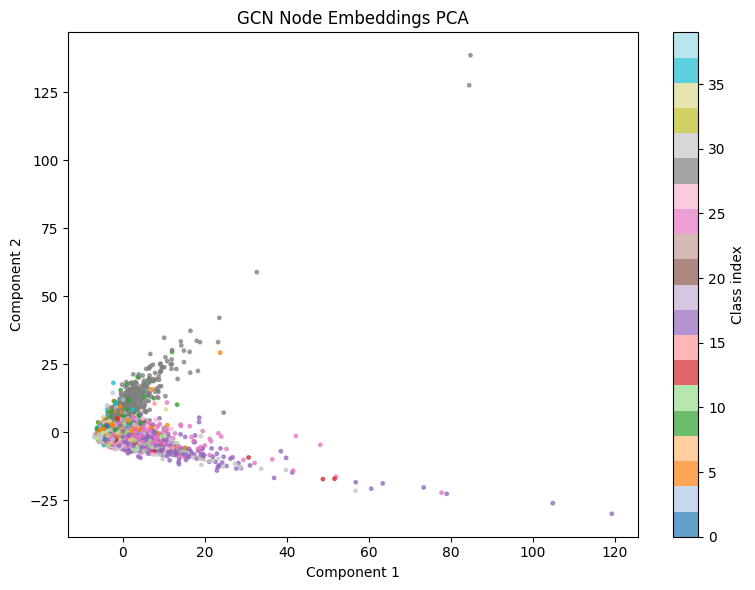

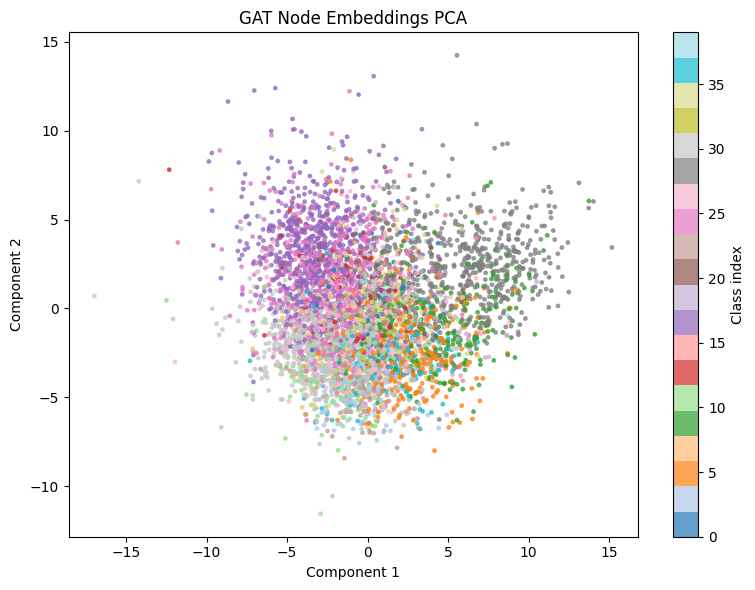

In [ ]:
# ============================================================
# PCA VISUALIZATION
# ============================================================

def plot_2d(
    emb_2d,
    labels_sample,
    title
):

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        emb_2d[:, 0],
        emb_2d[:, 1],
        c=labels_sample,
        cmap="tab20",
        s=6,
        alpha=0.7
    )

    plt.title(title)

    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.colorbar(
        scatter,
        label="Class index"
    )

    plt.tight_layout()

    filename = (
        title
        .replace(" ", "_")
        .replace(",", "")
        .replace("-", "")
    ) + ".png"

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# GCN PCA
# ------------------------------------------------------------

pca_gcn = PCA(
    n_components=2
).fit_transform(
    gcn_embeddings[sample_idx]
)

plot_2d(
    pca_gcn,
    labels[sample_idx],
    "GCN Node Embeddings PCA"
)


# ------------------------------------------------------------
# GAT PCA
# ------------------------------------------------------------

pca_gat = PCA(
    n_components=2
).fit_transform(
    gat_embeddings[sample_idx]
)

plot_2d(
    pca_gat,
    labels[sample_idx],
    "GAT Node Embeddings PCA"
)

# t-SNE visualization

Running GCN t-SNE...


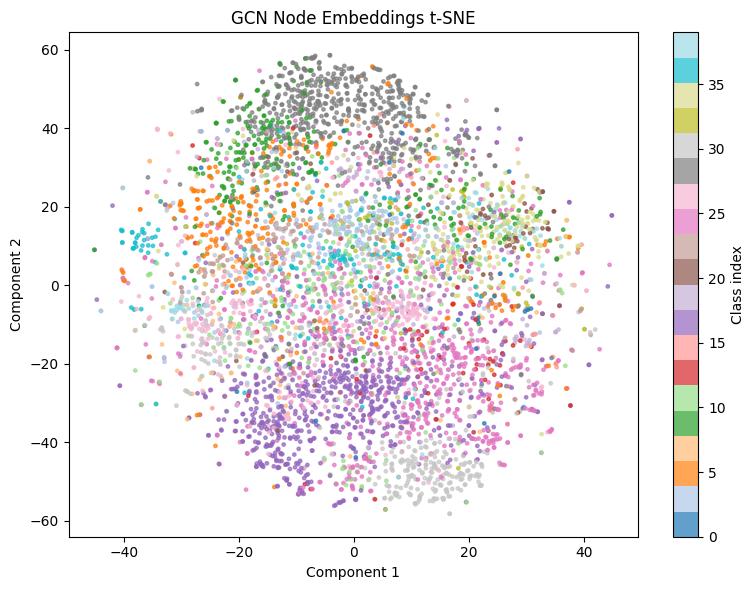

Running GAT t-SNE...


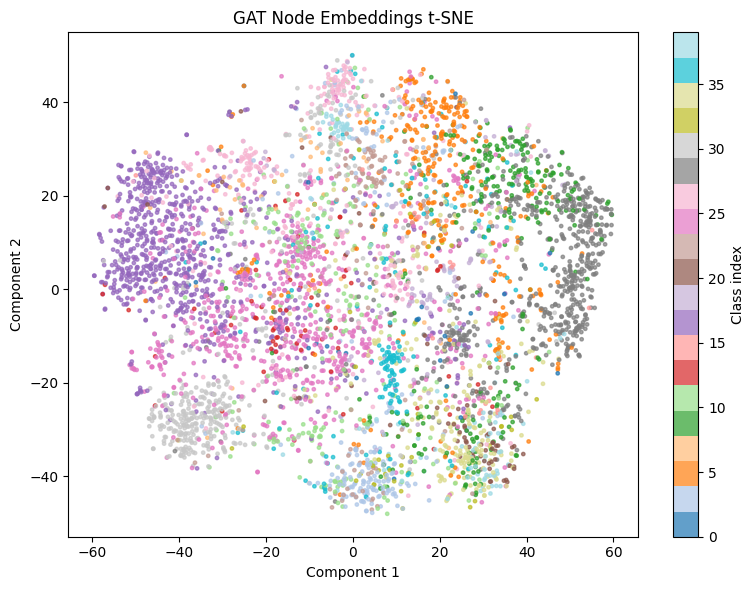

In [ ]:
# ============================================================
# t-SNE VISUALIZATION
# ============================================================

print("Running GCN t-SNE...")

tsne_gcn = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=42
).fit_transform(
    gcn_embeddings[sample_idx]
)

plot_2d(
    tsne_gcn,
    labels[sample_idx],
    "GCN Node Embeddings t-SNE"
)


print("Running GAT t-SNE...")

tsne_gat = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=42
).fit_transform(
    gat_embeddings[sample_idx]
)

plot_2d(
    tsne_gat,
    labels[sample_idx],
    "GAT Node Embeddings t-SNE"
)

# GAT attention analysis

Layer 1 edge index shape:
torch.Size([2, 1335586])

Layer 1 attention shape:
torch.Size([1335586, 4])


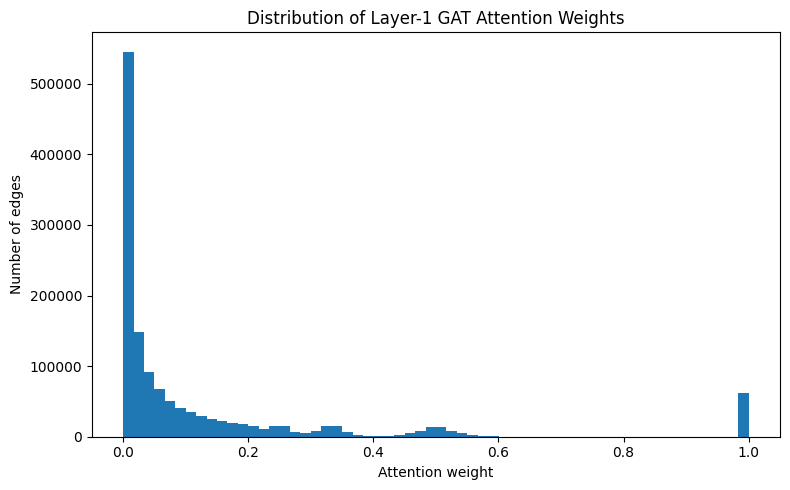

In [ ]:
# ============================================================
# GAT ATTENTION WEIGHT ANALYSIS
# ============================================================

with torch.no_grad():

    (
        out,
        embedding,
        (ei1, alpha1),
        (ei2, alpha2)
    ) = gat_model(
        data.x,
        data.edge_index,
        return_attention=True
    )


print("Layer 1 edge index shape:")
print(ei1.shape)

print("\nLayer 1 attention shape:")
print(alpha1.shape)


# Average attention across heads
if alpha1.dim() > 1:

    alpha1_mean = (
        alpha1
        .mean(dim=1)
        .cpu()
        .numpy()
    )

else:

    alpha1_mean = (
        alpha1
        .cpu()
        .numpy()
    )


# ------------------------------------------------------------
# Plot attention distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    alpha1_mean,
    bins=60
)

plt.title(
    "Distribution of Layer-1 GAT Attention Weights"
)

plt.xlabel("Attention weight")
plt.ylabel("Number of edges")

plt.tight_layout()

plt.savefig(
    "gat_attention_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Find top attended neighbors

In [ ]:
# ============================================================
# TOP ATTENDED NEIGHBORS
# ============================================================

def top_attended_neighbors(
    node_id,
    edge_index,
    alpha,
    k=5
):

    # Incoming edges
    mask = edge_index[1] == node_id

    src_nodes = (
        edge_index[0][mask]
        .cpu()
        .numpy()
    )

    weights = alpha[mask]

    # Average across attention heads
    if weights.dim() > 1:
        weights = weights.mean(dim=1)

    weights = (
        weights
        .cpu()
        .numpy()
    )

    if len(weights) == 0:
        return []

    order = np.argsort(
        -weights
    )[:k]

    return list(
        zip(
            src_nodes[order],
            weights[order]
        )
    )


# ------------------------------------------------------------
# Example nodes
# ------------------------------------------------------------

if test_idx is not None:

    example_positions = [
        0,
        min(10, len(test_idx) - 1),
        min(20, len(test_idx) - 1)
    ]

    for position in example_positions:

        example_node = int(
            test_idx[position].item()
        )

        print(
            f"\nNode {example_node} "
            f"(true class "
            f"{int(data.y[example_node].item())})"
            " — top attended neighbors:"
        )

        neighbors = top_attended_neighbors(
            example_node,
            ei1,
            alpha1,
            k=5
        )

        for src, weight in neighbors:

            cls = int(
                data.y[src].item()
            )

            print(
                f"  Paper {src} "
                f"(class {cls}) "
                f"-> attention weight "
                f"{weight:.4f}"
            )

else:

    print(
        "test_idx not available. "
        "Skipping example-node attention analysis."
    )


Node 346 (true class 24) — top attended neighbors:
  Paper 109114 (class 24) -> attention weight 0.3656
  Paper 346 (class 24) -> attention weight 0.3587
  Paper 87827 (class 24) -> attention weight 0.2756

Node 616 (true class 16) — top attended neighbors:
  Paper 616 (class 16) -> attention weight 0.3633
  Paper 115064 (class 16) -> attention weight 0.3206
  Paper 74095 (class 16) -> attention weight 0.3161

Node 694 (true class 25) — top attended neighbors:
  Paper 694 (class 25) -> attention weight 0.6307
  Paper 48505 (class 24) -> attention weight 0.3693


# Permutation feature importance

In [ ]:
# ============================================================
# PERMUTATION FEATURE IMPORTANCE
# ============================================================

def permutation_feature_importance(
    model,
    data,
    node_idx,
    n_repeats=3
):

    model.eval()

    # Baseline prediction
    with torch.no_grad():

        baseline_pred = (
            model(
                data.x,
                data.edge_index
            )[node_idx]
            .softmax(dim=-1)
        )


    n_features = data.x.size(1)

    importances = np.zeros(
        n_features
    )


    # Shuffle each feature
    for f in range(n_features):

        drops = []

        for _ in range(n_repeats):

            x_perturbed = data.x.clone()

            perm = torch.randperm(
                x_perturbed.size(0),
                device=x_perturbed.device
            )

            x_perturbed[:, f] = (
                x_perturbed[
                    perm,
                    f
                ]
            )


            # Prediction after permutation
            with torch.no_grad():

                pred = (
                    model(
                        x_perturbed,
                        data.edge_index
                    )[node_idx]
                    .softmax(dim=-1)
                )


            # Prediction change
            drops.append(
                (
                    baseline_pred - pred
                )
                .abs()
                .sum()
                .item()
            )


        importances[f] = np.mean(
            drops
        )


    return importances

# Run feature importance

In [ ]:
# ============================================================
# FEATURE IMPORTANCE - FAST VERSION
# ============================================================

def permutation_feature_importance_fast(
    model,
    data,
    node_indices,
    n_repeats=1,
    max_features=None
):
    """
    Faster permutation feature importance.

    Instead of running the model separately for every test node,
    we calculate predictions for all selected test nodes together.

    Parameters
    ----------
    model:
        Trained GCN or GAT model.

    data:
        PyTorch Geometric graph.

    node_indices:
        Nodes whose predictions will be analyzed.

    n_repeats:
        Number of permutations per feature.

    max_features:
        Maximum number of features to analyze.
        None = analyze all features.
    """

    model.eval()

    # --------------------------------------------------------
    # Convert node indices
    # --------------------------------------------------------

    if not torch.is_tensor(node_indices):

        node_indices = torch.tensor(
            node_indices,
            dtype=torch.long,
            device=data.x.device
        )

    else:

        node_indices = node_indices.to(
            data.x.device
        ).long()


    # --------------------------------------------------------
    # Number of features
    # --------------------------------------------------------

    n_features = data.x.size(1)

    if max_features is None:

        features_to_test = list(
            range(n_features)
        )

    else:

        features_to_test = list(
            range(
                min(
                    max_features,
                    n_features
                )
            )
        )


    # --------------------------------------------------------
    # Baseline prediction
    # --------------------------------------------------------

    with torch.no_grad():

        baseline_output = model(
            data.x,
            data.edge_index
        )

        baseline_prob = F.softmax(
            baseline_output[node_indices],
            dim=-1
        )


    # --------------------------------------------------------
    # Importance array
    # --------------------------------------------------------

    importances = np.zeros(
        len(features_to_test),
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Feature permutation
    # --------------------------------------------------------

    for position, feature in enumerate(
        features_to_test
    ):

        repeat_scores = []


        for repeat in range(
            n_repeats
        ):

            # Clone only once
            x_perturbed = data.x.clone()


            # Random permutation of feature values
            permutation = torch.randperm(
                x_perturbed.size(0),
                device=x_perturbed.device
            )


            x_perturbed[:, feature] = (
                x_perturbed[
                    permutation,
                    feature
                ]
            )


            # ------------------------------------------------
            # Prediction
            # ------------------------------------------------

            with torch.no_grad():

                perturbed_output = model(
                    x_perturbed,
                    data.edge_index
                )

                perturbed_prob = F.softmax(
                    perturbed_output[node_indices],
                    dim=-1
                )


            # ------------------------------------------------
            # Measure prediction change
            # ------------------------------------------------

            difference = (
                baseline_prob -
                perturbed_prob
            ).abs().sum(
                dim=1
            )


            score = difference.mean().item()

            repeat_scores.append(
                score
            )


        importances[position] = np.mean(
            repeat_scores
        )


        # Progress
        if (
            position + 1
        ) % 10 == 0 or (
            position + 1
        ) == len(features_to_test):

            print(
                f"Processed "
                f"{position + 1}/"
                f"{len(features_to_test)} "
                f"features"
            )


    return (
        np.array(features_to_test),
        importances
    )


# ============================================================
# RUN FEATURE IMPORTANCE
# ============================================================

print("=" * 60)
print("STARTING FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# Select test nodes
# ------------------------------------------------------------

number_of_nodes = min(
    15,
    len(test_idx)
)

sample_nodes = test_idx[
    :number_of_nodes
]


print(
    f"Analyzing {number_of_nodes} test nodes..."
)

print(
    "Node IDs:",
    sample_nodes.detach().cpu().tolist()
)


# ------------------------------------------------------------
# Run importance
# ------------------------------------------------------------

feature_indices, mean_importance = (
    permutation_feature_importance_fast(
        model=gcn_model,
        data=data,
        node_indices=sample_nodes,
        n_repeats=1,
        max_features=None
    )
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE COMPLETE")
print("=" * 60)

print(
    "Importance vector shape:",
    mean_importance.shape
)

print(
    "Number of features analyzed:",
    len(feature_indices)
)

print(
    "Highest importance:",
    mean_importance.max()
)

print(
    "Lowest importance:",
    mean_importance.min()
)

STARTING FEATURE IMPORTANCE ANALYSIS
Analyzing 15 test nodes...
Node IDs: [346, 398, 451, 480, 488, 490, 526, 537, 540, 602, 616, 666, 682, 683, 685]
Processed 10/128 features
Processed 20/128 features
Processed 30/128 features
Processed 40/128 features
Processed 50/128 features
Processed 60/128 features
Processed 70/128 features
Processed 80/128 features
Processed 90/128 features
Processed 100/128 features
Processed 110/128 features
Processed 120/128 features
Processed 128/128 features

FEATURE IMPORTANCE COMPLETE
Importance vector shape: (128,)
Number of features analyzed: 128
Highest importance: 0.3419641852378845
Lowest importance: 0.04212107136845589


# Plot feature importance

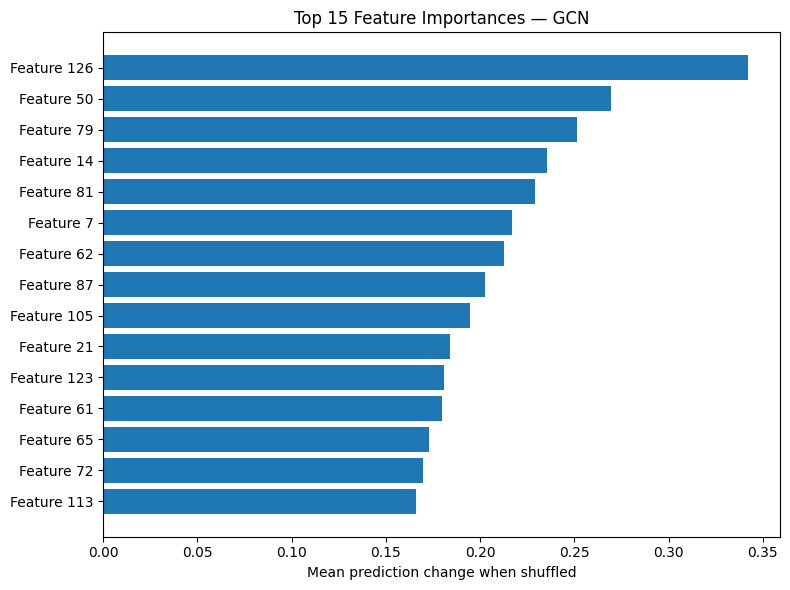


Top features:
Feature 126: 0.341964
Feature 50: 0.269240
Feature 79: 0.251155
Feature 14: 0.235439
Feature 81: 0.228898
Feature 7: 0.216953
Feature 62: 0.212686
Feature 87: 0.202376
Feature 105: 0.194404
Feature 21: 0.183828
Feature 123: 0.180919
Feature 61: 0.179563
Feature 65: 0.172890
Feature 72: 0.169418
Feature 113: 0.166151


In [ ]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

top_k = min(
    15,
    len(mean_importance)
)

top_features = np.argsort(
    -mean_importance
)[:top_k]


plt.figure(
    figsize=(8, 6)
)


plt.barh(
    [
        f"Feature {i}"
        for i in top_features
    ][::-1],

    mean_importance[
        top_features
    ][::-1]
)


plt.xlabel(
    "Mean prediction change when shuffled"
)

plt.title(
    f"Top {top_k} Feature Importances "
    "— GCN"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Print numerical results
print("\nTop features:")

for feature, importance in zip(
    top_features,
    mean_importance[top_features]
):

    print(
        f"Feature {feature}: "
        f"{importance:.6f}"
    )

# Neighborhood influence analysis

In [ ]:
# ============================================================
# NEIGHBORHOOD INFLUENCE ANALYSIS
# ============================================================

def neighborhood_influence(
    model,
    data,
    node_id
):

    model.eval()


    # --------------------------------------------------------
    # Baseline prediction
    # --------------------------------------------------------

    with torch.no_grad():

        baseline_pred = (
            model(
                data.x,
                data.edge_index
            )[node_id]
            .softmax(dim=-1)
        )


    # --------------------------------------------------------
    # Incoming citation edges
    # --------------------------------------------------------

    incoming_mask = (
        data.edge_index[1] == node_id
    )

    incoming_edges = (
        incoming_mask
        .nonzero(as_tuple=True)[0]
    )


    influences = []


    # --------------------------------------------------------
    # Remove one edge at a time
    # --------------------------------------------------------

    for e in incoming_edges:

        edge_mask = torch.ones(
            data.edge_index.size(1),
            dtype=torch.bool,
            device=data.edge_index.device
        )

        edge_mask[e] = False


        reduced_edge_index = (
            data.edge_index[
                :,
                edge_mask
            ]
        )


        # Prediction without this neighbor
        with torch.no_grad():

            pred = (
                model(
                    data.x,
                    reduced_edge_index
                )[node_id]
                .softmax(dim=-1)
            )


        # Prediction change
        influence = (
            baseline_pred - pred
        ).abs().sum().item()


        # Source node
        source_node = (
            data.edge_index[
                0,
                e
            ].item()
        )


        influences.append(
            (
                source_node,
                influence
            )
        )


    # Sort by largest influence
    influences.sort(
        key=lambda t: -t[1]
    )


    return influences

# Run neighborhood influence

In [ ]:
# ============================================================
# RUN NEIGHBORHOOD INFLUENCE
# ============================================================

if test_idx is not None:

    example_position = min(
        5,
        len(test_idx) - 1
    )

    example_node = int(
        test_idx[
            example_position
        ].item()
    )


    print(
        f"Analyzing neighborhood influence "
        f"for node {example_node}..."
    )


    influences = neighborhood_influence(
        gcn_model,
        data,
        example_node
    )


    print(
        f"\nMost influential neighbors "
        f"of node {example_node} "
        f"(true class "
        f"{int(data.y[example_node].item())}):"
    )


    for src, influence in influences[:5]:

        source_class = int(
            data.y[src].item()
        )

        print(
            f"  Paper {src} "
            f"(class {source_class}) "
            f"-> influence "
            f"{influence:.4f}"
        )

else:

    print(
        "test_idx is not available. "
        "Skipping neighborhood influence analysis."
    )

Analyzing neighborhood influence for node 490...

Most influential neighbors of node 490 (true class 28):
  Paper 89927 (class 8) -> influence 0.4527
  Paper 72307 (class 28) -> influence 0.1434
  Paper 91132 (class 28) -> influence 0.0281
  Paper 66245 (class 28) -> influence 0.0244
  Paper 102508 (class 28) -> influence 0.0235


# Final summary

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 60)
print("TASK 07 — GRAPH EXPLAINABILITY")
print("=" * 60)

print("\nDataset:")
print(f"  Nodes:    {data.num_nodes:,}")
print(f"  Edges:    {data.num_edges:,}")
print(f"  Features: {in_channels}")
print(f"  Classes:  {num_classes}")

print("\nModels:")
print("  ✓ GCN")
print("  ✓ GAT")

print("\nExplainability analyses:")
print("  ✓ PCA node embeddings")
print("  ✓ t-SNE node embeddings")
print("  ✓ GAT attention weights")
print("  ✓ Top attended neighbors")
print("  ✓ Permutation feature importance")
print("  ✓ Neighborhood influence")

print("\nGenerated files:")
print("  ✓ GCN_Node_Embeddings_PCA.png")
print("  ✓ GAT_Node_Embeddings_PCA.png")
print("  ✓ GCN_Node_Embeddings_tSNE.png")
print("  ✓ GAT_Node_Embeddings_tSNE.png")
print("  ✓ gat_attention_distribution.png")
print("  ✓ feature_importance.png")

print("\nTask 07 completed.")

TASK 07 — GRAPH EXPLAINABILITY

Dataset:
  Nodes:    169,343
  Edges:    1,166,243
  Features: 128
  Classes:  40

Models:
  ✓ GCN
  ✓ GAT

Explainability analyses:
  ✓ PCA node embeddings
  ✓ t-SNE node embeddings
  ✓ GAT attention weights
  ✓ Top attended neighbors
  ✓ Permutation feature importance
  ✓ Neighborhood influence

Generated files:
  ✓ GCN_Node_Embeddings_PCA.png
  ✓ GAT_Node_Embeddings_PCA.png
  ✓ GCN_Node_Embeddings_tSNE.png
  ✓ GAT_Node_Embeddings_tSNE.png
  ✓ gat_attention_distribution.png
  ✓ feature_importance.png

Task 07 completed.
